In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
df=pd.read_csv("/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv")
df.sample(8)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6205,s6206,Movie,Babel,Alejandro G. Iñárritu,"Brad Pitt, Cate Blanchett, Gael García Bernal,...","France, United States, Mexico","January 1, 2019",2006,R,143 min,"Dramas, Independent Movies",When an American couple vacationing in Morocco...
644,s645,Movie,Good on Paper,Kimmy Gatewood,"Iliza Shlesinger, Ryan Hansen, Margaret Cho, R...",NaN,"June 23, 2021",2021,TV-MA,94 min,"Comedies, Romantic Movies","After years of putting her career first, a sta..."
2893,s2894,TV Show,Passion. Panache. Pep,NaN,NaN,NaN,"February 21, 2020",2020,TV-G,1 Season,"International TV Shows, Reality TV",From delicious delicacies to dream destination...
2543,s2544,Movie,Unbreakable Kimmy Schmidt: Kimmy vs. the Reverend,Claire Scanlon,"Ellie Kemper, Jane Krakowski, Tituss Burgess, ...",United States,"May 12, 2020",2020,TV-14,190 min,Comedies,It's an interactive Kimmy special! Kimmy's get...
180,s181,Movie,The Nutty Professor II: The Klumps,Peter Segal,"Eddie Murphy, Janet Jackson, Larry Miller, Joh...",NaN,"September 1, 2021",2000,PG-13,107 min,"Comedies, Romantic Movies","After getting engaged, Sherman Klump prepares ..."
6956,s6957,Movie,Hell or High Water,David Mackenzie,"Jeff Bridges, Chris Pine, Ben Foster, Gil Birm...",United States,"January 1, 2019",2016,R,102 min,"Dramas, Independent Movies","In a desperate bid to save their family ranch,..."
5581,s5582,Movie,The Butterfly's Dream,Yılmaz Erdoğan,"Kıvanç Tatlıtuğ, Mert Fırat, Belçim Bilgin, Fa...",Turkey,"March 10, 2017",2013,TV-PG,118 min,"Dramas, International Movies, Romantic Movies",Forced to work in a coal mine during World War...
2829,s2830,Movie,Marc Maron: End Times Fun,Lynn Shelton,Marc Maron,United States,"March 10, 2020",2020,TV-MA,71 min,Stand-Up Comedy,Marc Maron wades through a swamp of vitamin hu...


<h1 style="font-size:50px; font-family:Garamond; font-weight:normal;  color:black ; text-align:center; ">
Missing Values Analysis
</h1>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [6]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal;  color:black ; text-align:center; ">
Missing Values Treatment
</h1>

In [8]:
df['director'].fillna('Unknown',inplace=True)
df['cast'].fillna('Unknown',inplace=True)
df['country'].fillna('Not Specified',inplace=True)
df['date_added'].fillna('Not Available',inplace=True)
df['rating'].fillna(df['rating'].mode()[0]  if not df['rating'].mode().empty else 'Not Rated',inplace=True)

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal;  color:black ; text-align:center; ">
Content Type Distribution
</h1>



In [9]:
df['release_year'].agg(['min','max'])

min    1925
max    2021
Name: release_year, dtype: int64

In [10]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal;  color:black ; text-align:center; ">
Data Visulization
</h1>


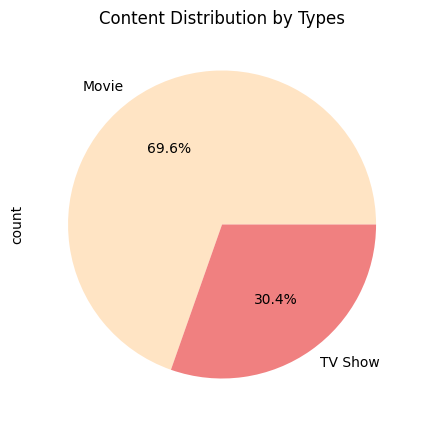

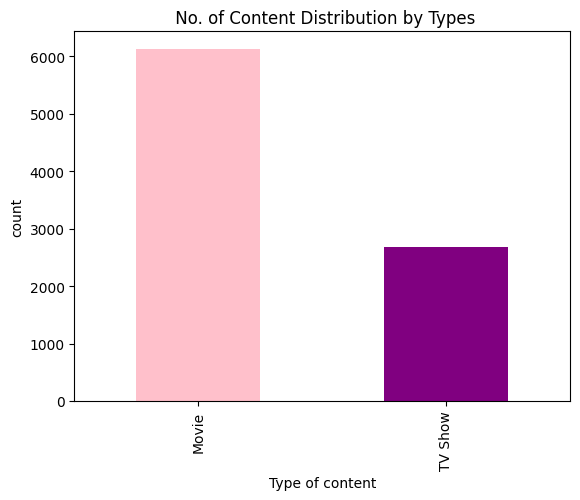

In [11]:
plt.figure(figsize=(7,5))
df['type'].value_counts().plot(kind='pie',autopct="%1.1f%%" ,colors=["bisque","lightcoral"])
plt.title("Content Distribution by Types")
plt.show()

df['type'].value_counts().plot(kind="bar",color=["pink","purple"])
plt.title(" No. of Content Distribution by Types")
plt.xlabel("Type of content")
plt.ylabel("count")
plt.show()

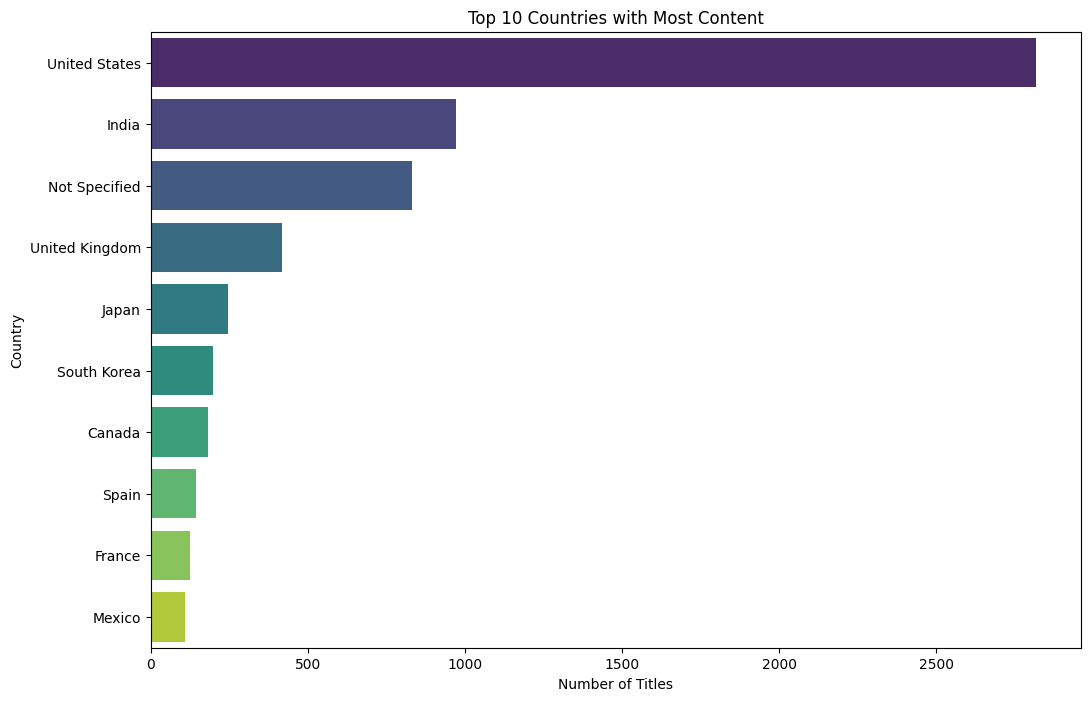

In [12]:
top_countries=df['country'].value_counts().head(10)

plt.figure(figsize=(12,8))
sns.barplot(x=top_countries.values , y=top_countries.index,palette="viridis")
plt.title('Top 10 Countries with Most Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

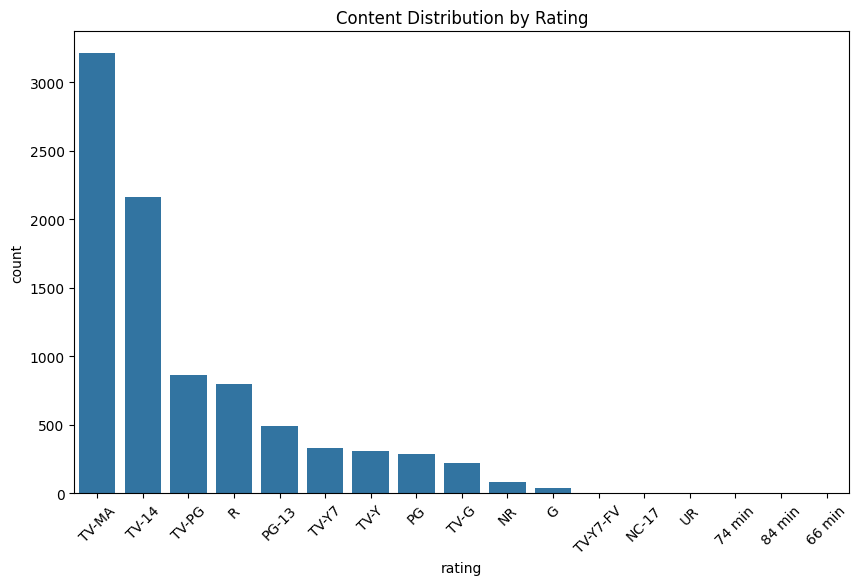

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='rating' , order=df['rating'].value_counts().index)
plt.title("Content Distribution by Rating")
plt.xticks(rotation=45)
plt.show()

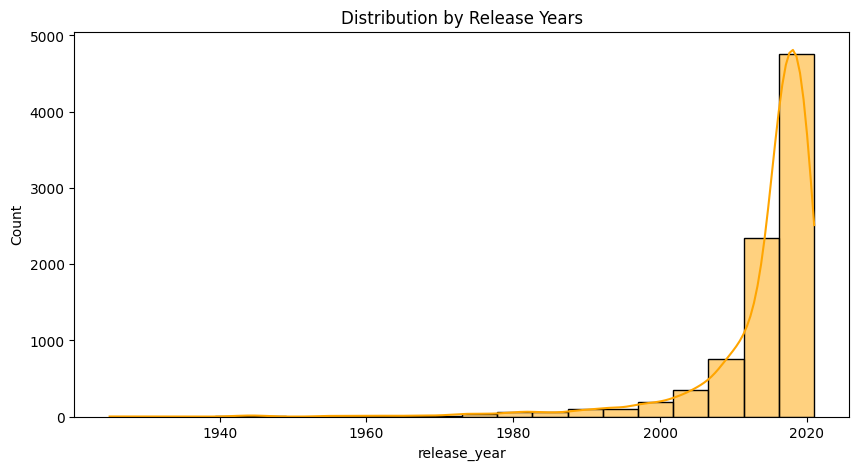

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'],kde=True, bins=20,color="orange")
plt.title('Distribution by Release Years')
plt.ylabel('Count')
plt.show()

